In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src.visualization import plot_forecast
from src.models.rnn.rnn_regressor import RNNRegressor
from src.models.rnn.train_rnn_recursive import train_rnn_recursive
from src.models.rnn.predict import get_full_predict
from src.evaluation import evaluate, evaluate_by_depth
from src.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
set_seed(SEED)

In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size, shuffle=False)

In [10]:
val_future_features_tensor = torch.tensor(
    val_scaled[lags_length:, :len(features_cols)], 
    dtype=torch.float32
).to(device)

input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    set_seed(SEED + trial.number)
    hidden_size = trial.suggest_int('hidden_size', 16, 160, step=16)
    num_layers = trial.suggest_int('num_layers', 2, 5)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    model_trial = RNNRegressor(
        input_size,
        hidden_size,
        num_layers,
        output_size,
        dropout=dropout,
        rnn_type='lstm'
    ).to(device)
    optimizer_trial = optim.AdamW(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    model_trial, history = train_rnn_recursive(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        val_future_features=val_future_features_tensor,
        scheduler=scheduler,
        epochs=100,
        max_epochs_no_improvement=20,
        device=device,
        verbose=False
    )
    
    trial.set_user_attr('best_epoch', history['best_epoch'])
    trial.set_user_attr('total_epochs', len(history['val_rmse']))
    
    best_val_rmse = float(history['best_val_rmse'][-1])
    return best_val_rmse

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=20)

print('Лучшие параметры: ', study.best_params)
print('Количество эпох в лучшем запуске: ', study.best_trial.user_attrs['total_epochs'])

[I 2026-06-11 00:38:18,473] A new study created in memory with name: no-name-c2cde92b-bf3f-4205-b4f0-b077d07f39bd
[I 2026-06-11 00:38:34,481] Trial 0 finished with value: 0.35264334082603455 and parameters: {'hidden_size': 64, 'num_layers': 5, 'dropout': 0.39279757672456206, 'lr': 0.00015751320499779721, 'weight_decay': 2.9380279387035354e-06}. Best is trial 0 with value: 0.35264334082603455.


Early stopping on 41 epoch


[I 2026-06-11 00:38:43,896] Trial 1 finished with value: 0.6386521458625793 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.4464704583099741, 'lr': 0.00015930522616241006, 'weight_decay': 0.000133112160807369}. Best is trial 0 with value: 0.35264334082603455.


Early stopping on 34 epoch


[I 2026-06-11 00:39:18,137] Trial 2 finished with value: 0.844784140586853 and parameters: {'hidden_size': 16, 'num_layers': 5, 'dropout': 0.4329770563201687, 'lr': 2.6587543983272695e-05, 'weight_decay': 3.5113563139704077e-06}. Best is trial 0 with value: 0.35264334082603455.
[I 2026-06-11 00:39:31,559] Trial 3 finished with value: 0.7285633683204651 and parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.3099025726528951, 'lr': 7.309539835912905e-05, 'weight_decay': 7.4763120622522945e-06}. Best is trial 0 with value: 0.35264334082603455.


...

Early stopping on 32 epoch


[I 2026-06-11 00:43:35,842] Trial 18 finished with value: 0.28376704454421997 and parameters: {'hidden_size': 80, 'num_layers': 2, 'dropout': 0.15453614054025627, 'lr': 0.0003801293272819374, 'weight_decay': 1.5217635313825486e-05}. Best is trial 4 with value: 0.24712181091308594.


Early stopping on 50 epoch


[I 2026-06-11 00:44:03,662] Trial 19 finished with value: 0.5575695037841797 and parameters: {'hidden_size': 160, 'num_layers': 3, 'dropout': 0.48770794081948715, 'lr': 1.0519095028133849e-05, 'weight_decay': 0.00028916657147930104}. Best is trial 4 with value: 0.24712181091308594.


Early stopping on 56 epoch
Лучшие параметры:  {'hidden_size': 112, 'num_layers': 2, 'dropout': 0.21685785941408728, 'lr': 5.4041038546473305e-05, 'weight_decay': 2.334586407601622e-05}
Количество эпох в лучшем запуске:  69


In [11]:
#input_size = full_train_scaled.shape[1]
set_seed(SEED)
model = RNNRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size,
    dropout=study.best_params['dropout'],
    rnn_type='lstm'
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_params['lr'],
    weight_decay=study.best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

model, _ = train_rnn_recursive(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    scheduler=scheduler,
    epochs=study.best_trial.user_attrs['best_epoch'],
    max_epochs_no_improvement=20,
    device=device,
    verbose=True
)

Epoch 1/49 | Train Loss: 0.9875
Epoch 2/49 | Train Loss: 0.9681
Epoch 3/49 | Train Loss: 0.9471
Epoch 4/49 | Train Loss: 0.9205
Epoch 5/49 | Train Loss: 0.8875
Epoch 6/49 | Train Loss: 0.8439
Epoch 7/49 | Train Loss: 0.7854
Epoch 8/49 | Train Loss: 0.7090
Epoch 9/49 | Train Loss: 0.6177
Epoch 10/49 | Train Loss: 0.5211
Epoch 11/49 | Train Loss: 0.4358
Epoch 12/49 | Train Loss: 0.3698
Epoch 13/49 | Train Loss: 0.3215
Epoch 14/49 | Train Loss: 0.2868
Epoch 15/49 | Train Loss: 0.2606
Epoch 16/49 | Train Loss: 0.2422
Epoch 17/49 | Train Loss: 0.2271
Epoch 18/49 | Train Loss: 0.2149
Epoch 19/49 | Train Loss: 0.2051
Epoch 20/49 | Train Loss: 0.1954
Epoch 21/49 | Train Loss: 0.1876
Epoch 22/49 | Train Loss: 0.1799
Epoch 23/49 | Train Loss: 0.1718
Epoch 24/49 | Train Loss: 0.1641
Epoch 25/49 | Train Loss: 0.1569
Epoch 26/49 | Train Loss: 0.1491
Epoch 27/49 | Train Loss: 0.1411
Epoch 28/49 | Train Loss: 0.1337
Epoch 29/49 | Train Loss: 0.1258
Epoch 30/49 | Train Loss: 0.1177
Epoch 31/49 | Train

In [15]:
model_path = 'models/lstm_v4.pth'
weights_path = 'models/lstm_v4_weights.pth'

torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

model = torch.load(model_path, weights_only=False)

                              RMSE      MAE        ME       NSE
Значение для всех глубин  0.802395  0.65163 -0.160963  0.943249
      48-1 (0)
RMSE  3.006121
MAE   2.434039
ME   -0.731854
NSE    0.89578


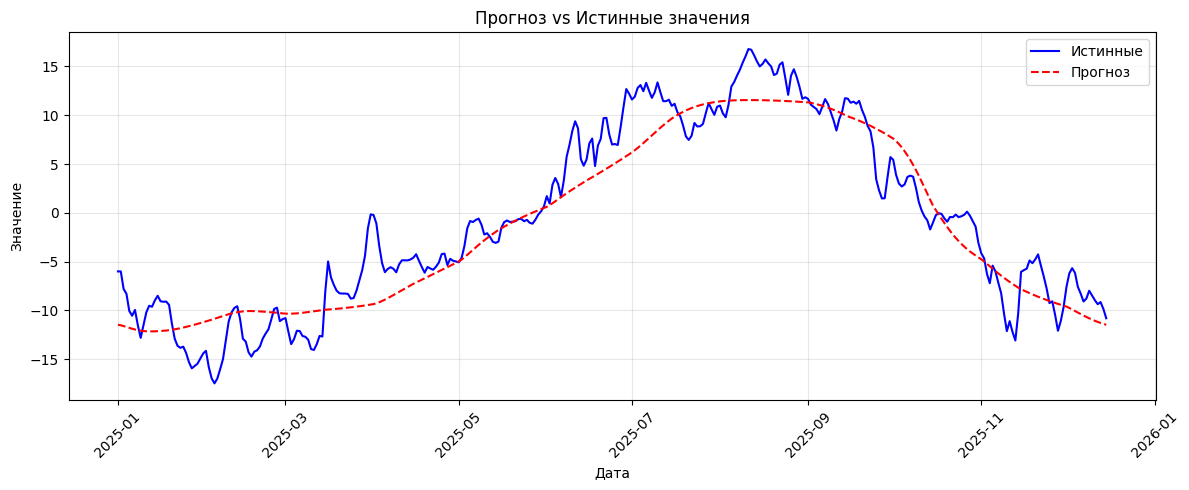

     48-1 (0,5)
RMSE   1.959029
MAE    1.550693
ME    -0.524616
NSE     0.92185


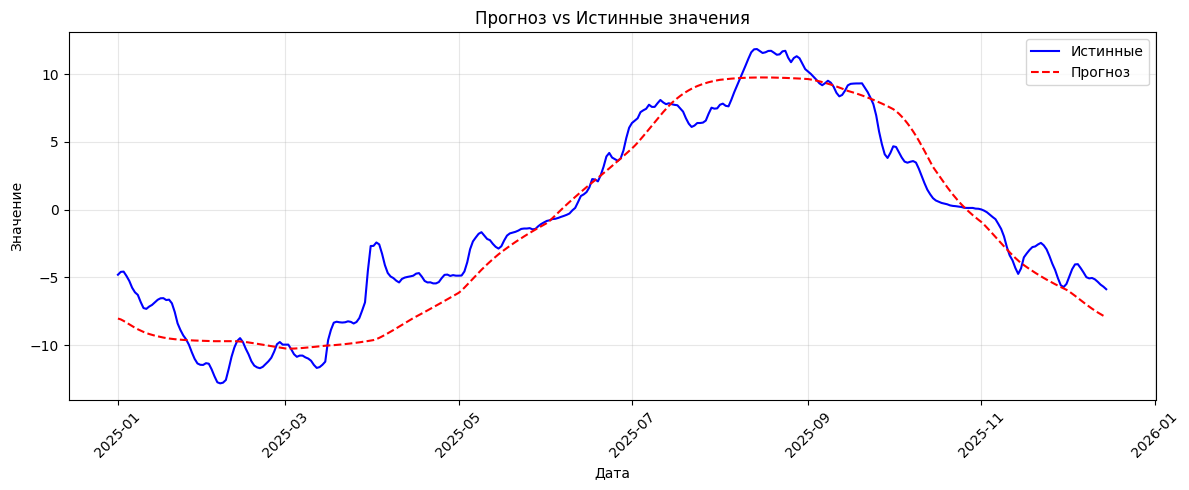

      48-1 (1)
RMSE  1.419415
MAE   1.129536
ME   -0.276102
NSE   0.931255


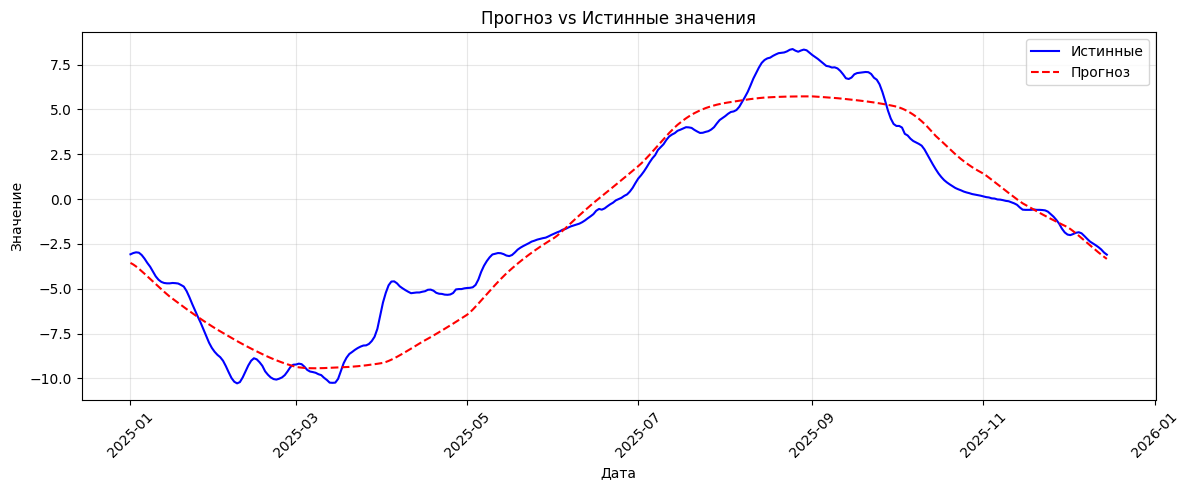

     48-1 (1,5)
RMSE   1.263404
MAE    1.082678
ME    -0.167587
NSE    0.916846


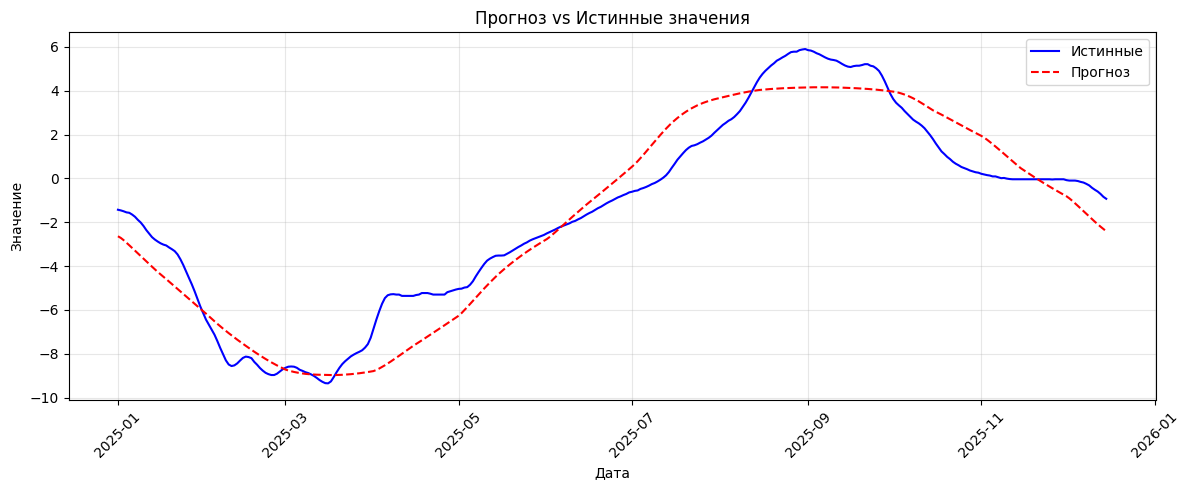

      48-1 (2)
RMSE  1.048703
MAE   0.891046
ME   -0.079415
NSE   0.910576


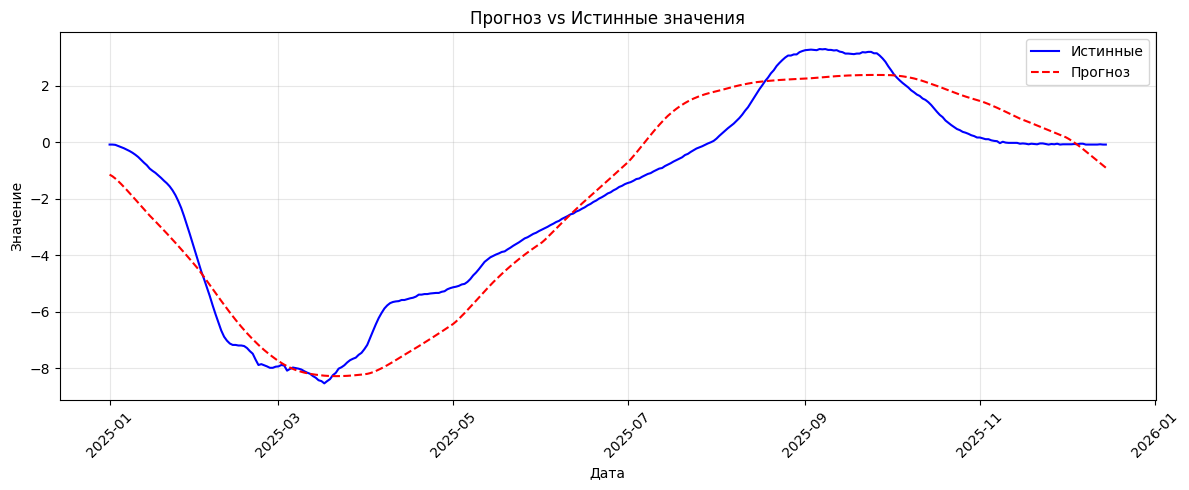

     48-1 (2,5)
RMSE   0.612317
MAE    0.467731
ME     -0.09613
NSE    0.951146


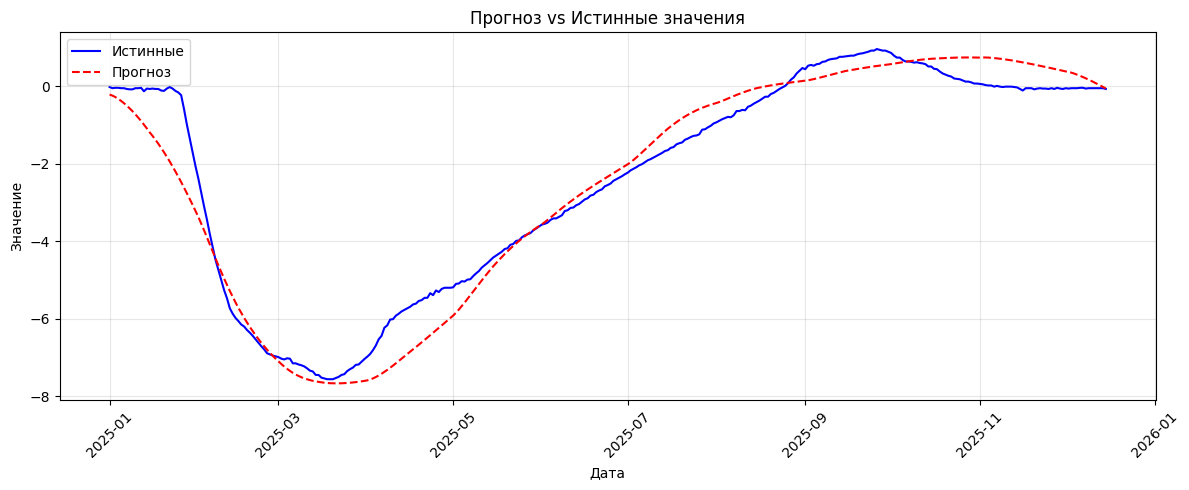

      48-1 (3)
RMSE  0.493374
MAE   0.344914
ME   -0.133955
NSE   0.959132


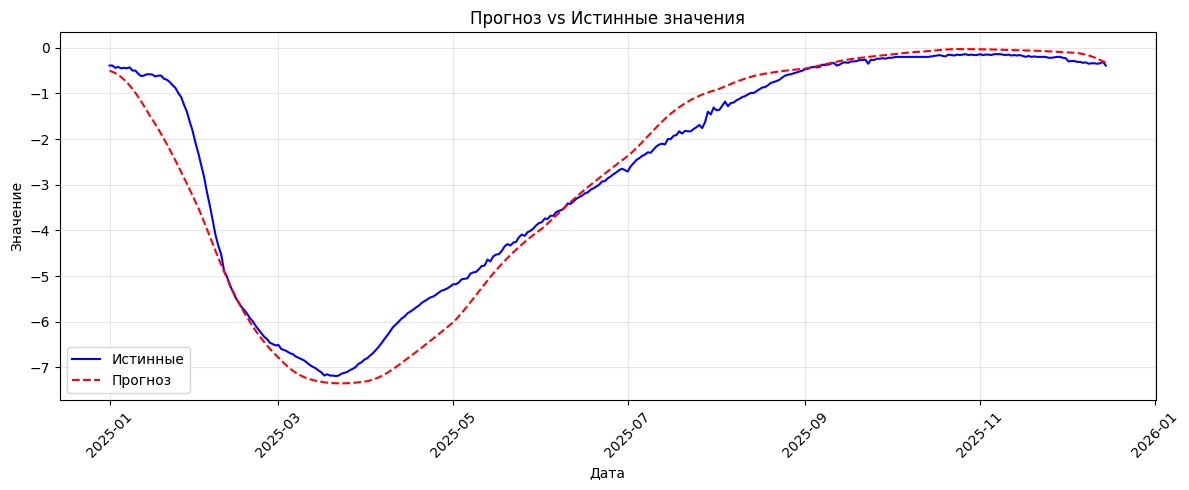

     48-1 (3,5)
RMSE   0.427787
MAE    0.345422
ME    -0.109749
NSE    0.963368


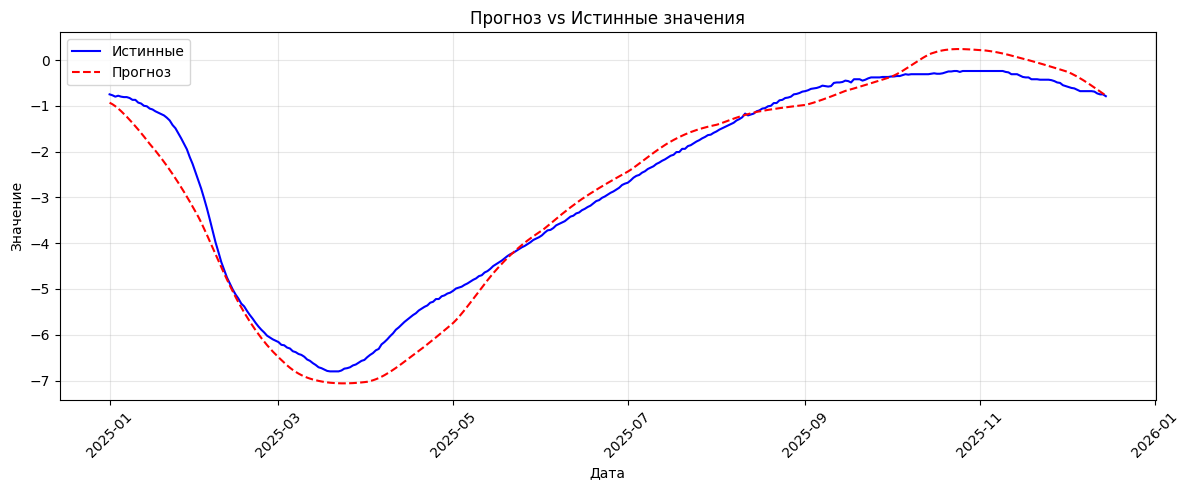

      48-1 (4)
RMSE  0.451143
MAE    0.35734
ME   -0.121827
NSE   0.950376


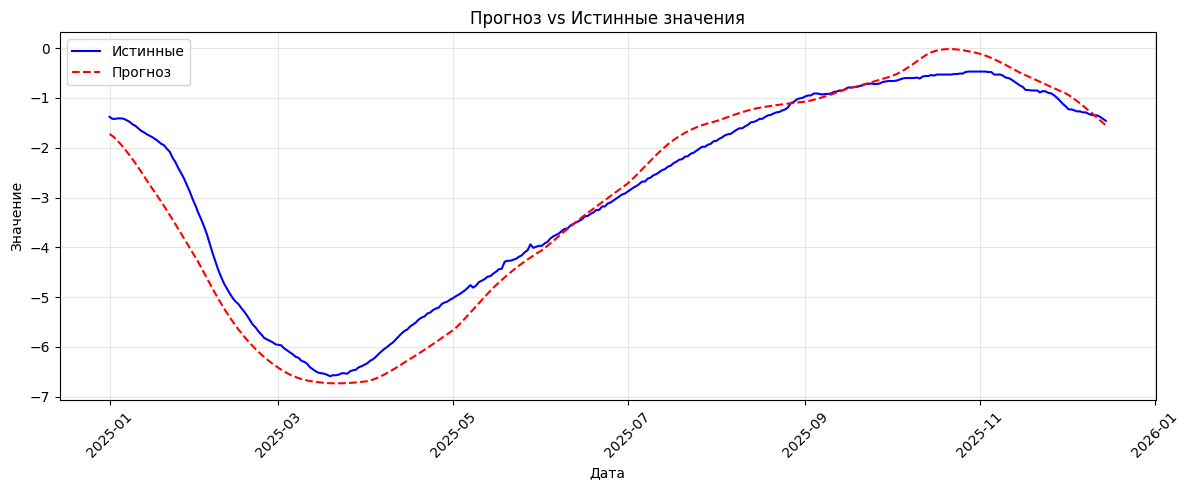

     48-1 (4,5)
RMSE   0.410496
MAE    0.347914
ME    -0.178758
NSE    0.954647


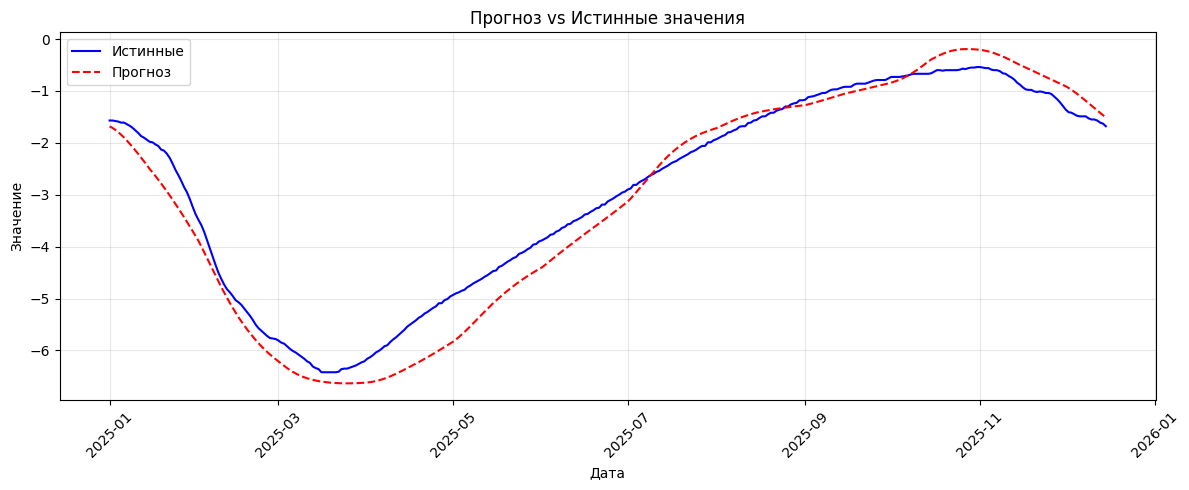

      48-1 (5)
RMSE  0.391913
MAE   0.310138
ME   -0.153079
NSE   0.954336


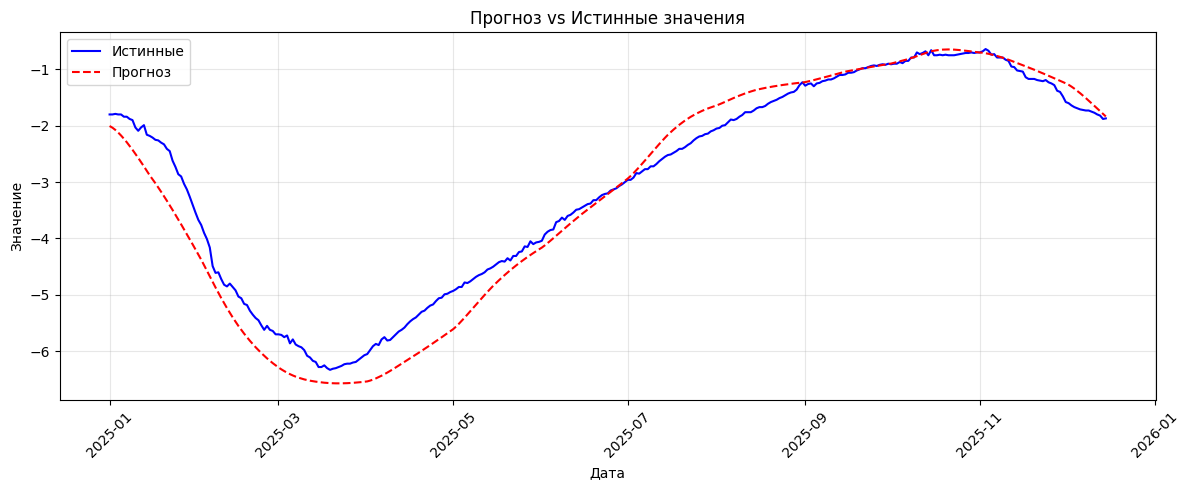

      48-1 (6)
RMSE  0.368042
MAE    0.30858
ME    -0.04801
NSE    0.95181


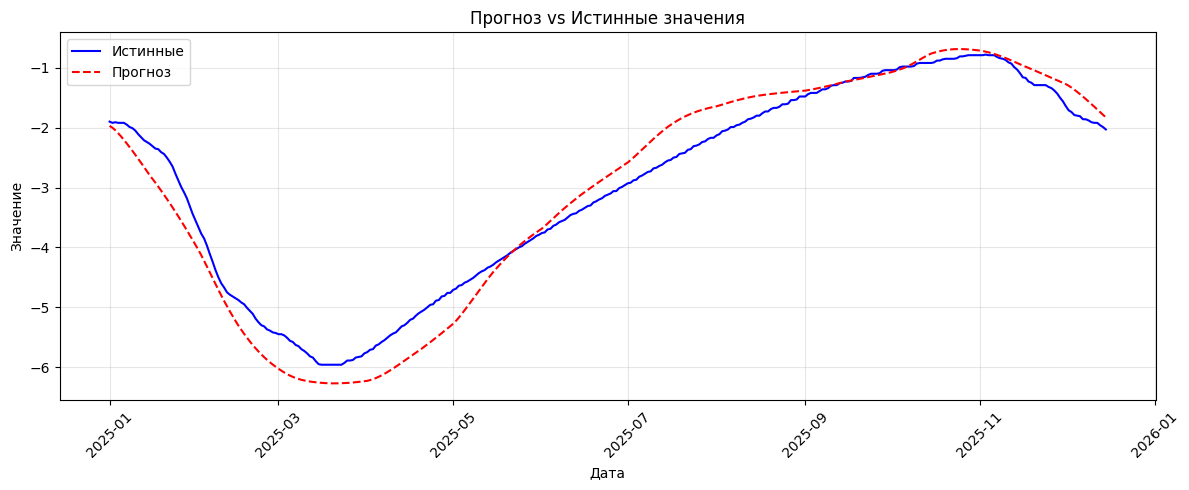

      48-1 (7)
RMSE  0.333922
MAE   0.282487
ME   -0.106419
NSE   0.951586


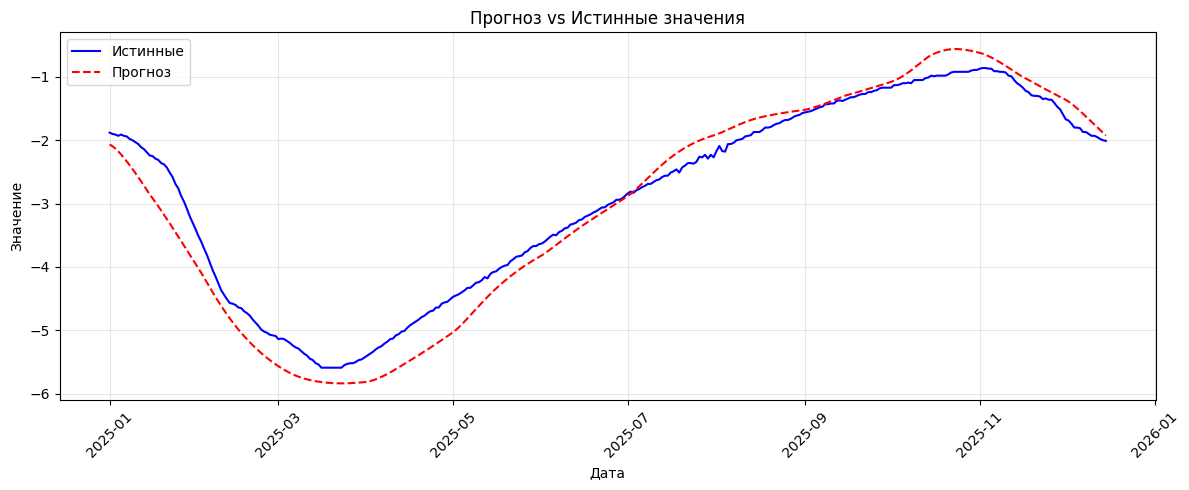

      48-1 (8)
RMSE   0.27534
MAE   0.243736
ME   -0.009849
NSE   0.956555


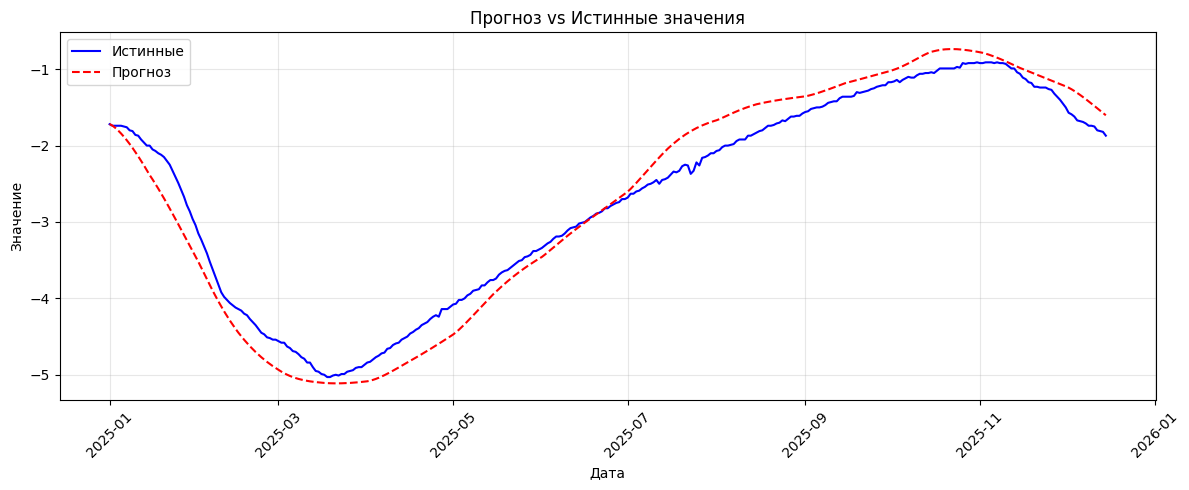

      48-1 (9)
RMSE  0.210172
MAE   0.183799
ME    0.052326
NSE   0.961956


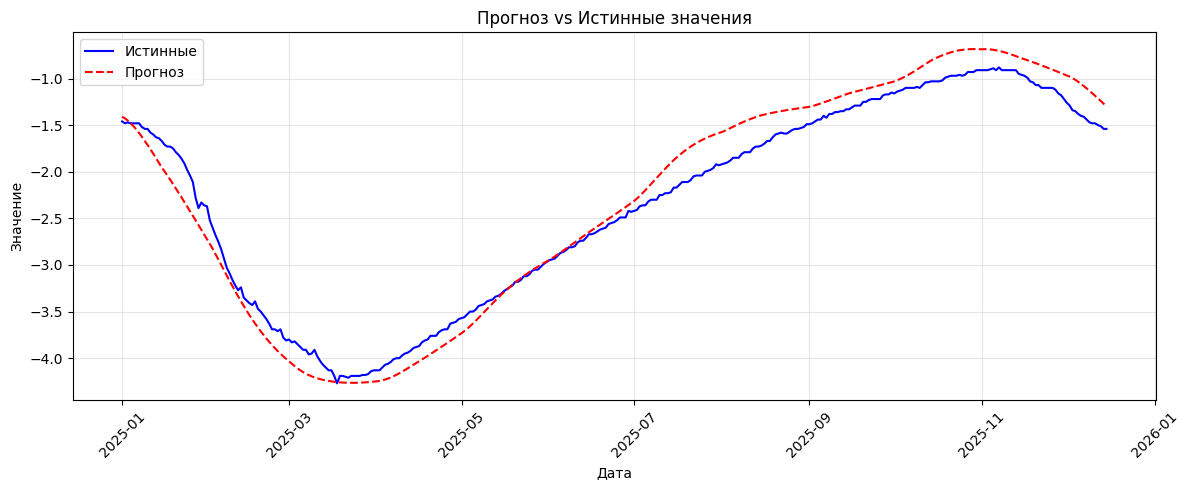

     48-1 (10)
RMSE  0.167143
MAE   0.146023
ME    0.109624
NSE   0.960768


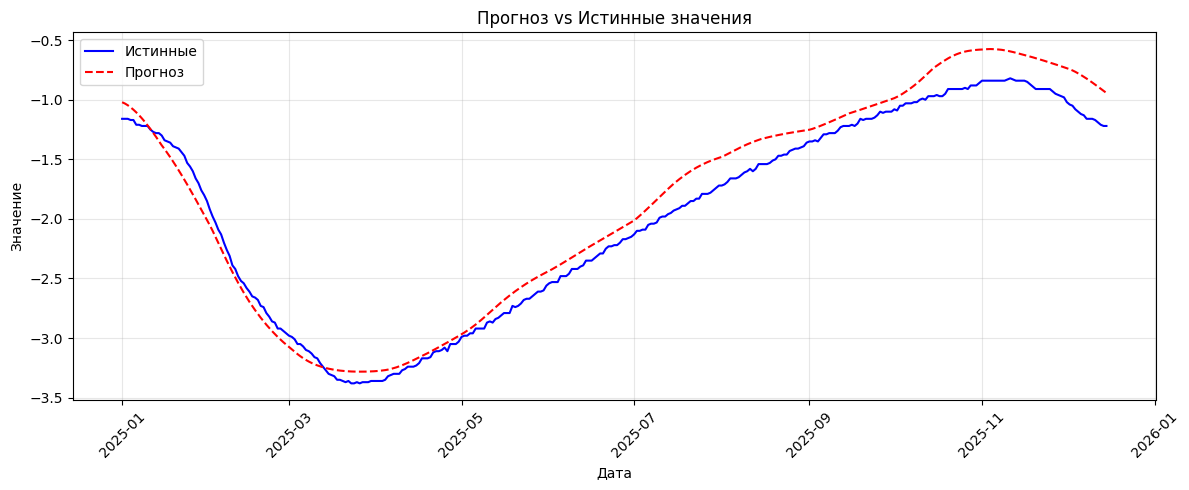

In [13]:
test_start = df_train_full[-lags_length:]

y_pred = get_full_predict(
    model=model,
    df_test=df_test,
    test_start=test_start,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    features_cols=features_cols,
    target_cols=target_cols,
    device=device
)
y_true = df_test[target_cols].values

eval_dict = evaluate(y_true, y_pred)
print(pd.DataFrame(eval_dict, index=['Значение для всех глубин']))

eval_by_depth_df = evaluate_by_depth(y_true, y_pred, target_cols)
for i, col in enumerate(target_cols):
    metrics = eval_by_depth_df.loc[col]
    print(metrics.to_frame()[1:])
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))